In [39]:
#importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [40]:
#Loading Dataset

train_df = pd.read_csv("E:/Laptop/Clickstream/Data/train_data - train_data.csv")
test_df = pd.read_csv("E:/Laptop/Clickstream/Data/test_data - test_data.csv")

In [41]:
print(train_df.shape)


(132379, 14)


In [42]:
train_df.head()

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2


In [43]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132379 entries, 0 to 132378
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   year                  132379 non-null  int64 
 1   month                 132379 non-null  int64 
 2   day                   132379 non-null  int64 
 3   order                 132379 non-null  int64 
 4   country               132379 non-null  int64 
 5   session_id            132379 non-null  int64 
 6   page1_main_category   132379 non-null  int64 
 7   page2_clothing_model  132379 non-null  object
 8   colour                132379 non-null  int64 
 9   location              132379 non-null  int64 
 10  model_photography     132379 non-null  int64 
 11  price                 132379 non-null  int64 
 12  price_2               132379 non-null  int64 
 13  page                  132379 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 14.1+ MB


In [44]:
train_df.describe()

,year,month,day,order,country,session_id,page1_main_category,colour,location,model_photography,price,price_2,page
count,132379.0,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000
mean,2008.0,5.582759,14.507671,9.811314,26.949629,12038.722063,2.400426,6.227393,3.261106,1.260026,43.788191,1.488484,1.712137
std,0.0,1.328064,8.829106,13.458937,7.153071,7012.460866,1.145004,4.238354,1.714058,0.438650,12.539390,0.499869,0.983699
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5905.000000,1.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11931.000000,2.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18212.000000,3.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


In [45]:
train_df.isnull().sum()

year                    0
month                   0
day                     0
order                   0
country                 0
session_id              0
page1_main_category     0
page2_clothing_model    0
colour                  0
location                0
model_photography       0
price                   0
price_2                 0
page                    0
dtype: int64

In [46]:
train_df.columns

Index(['year', 'month', 'day', 'order', 'country', 'session_id',
       'page1_main_category', 'page2_clothing_model', 'colour', 'location',
       'model_photography', 'price', 'price_2', 'page'],
      dtype='object')

In [47]:
#Year distribution
train_df['year'].value_counts()# year is same for all rows, so we can drop this column

year
2008    132379
Name: count, dtype: int64

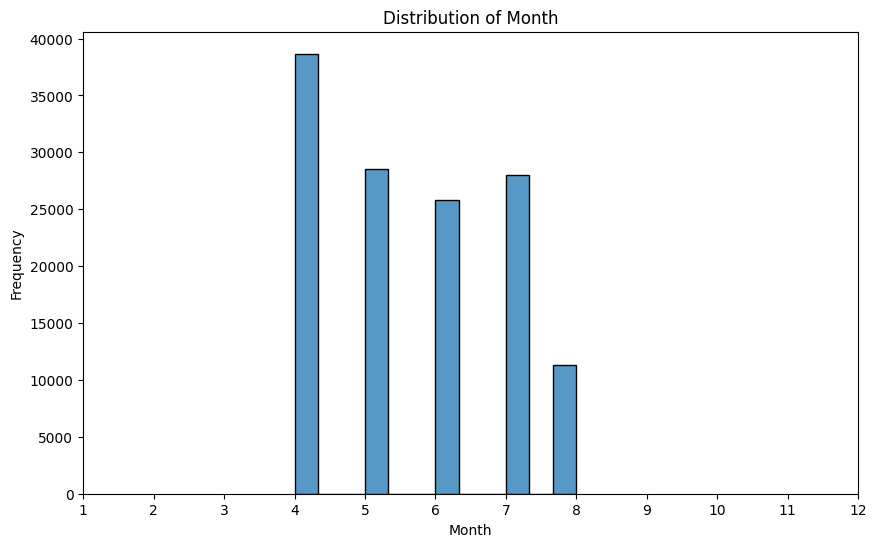

In [48]:
#Month distribution using histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['month'], bins=12, kde=False)
plt.title('Distribution of Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.xticks(range(1, 13))
plt.show()


In [49]:
#month-unique values
train_df["month"].value_counts()# months 4,5,6,7,8 have date, other months have no entries

month
4    38664
5    28572
7    28032
6    25794
8    11317
Name: count, dtype: int64

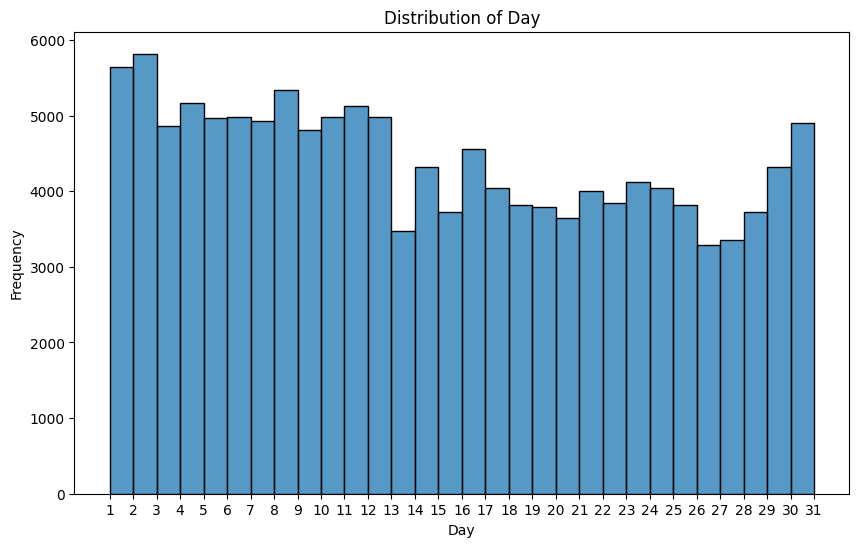

In [50]:
#Day distribution using histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['day'], bins=30, kde=False)
plt.title('Distribution of Day')
plt.xlabel('Day')
plt.ylabel('Frequency')
plt.xticks(range(1, 32))
plt.show()

In [51]:
#correlation between order and price_2
correlation = train_df['order'].corr(train_df['price_2'])
print(f"Correlation between order and price_2: {correlation}")

Correlation between order and price_2: 0.00075157023081946


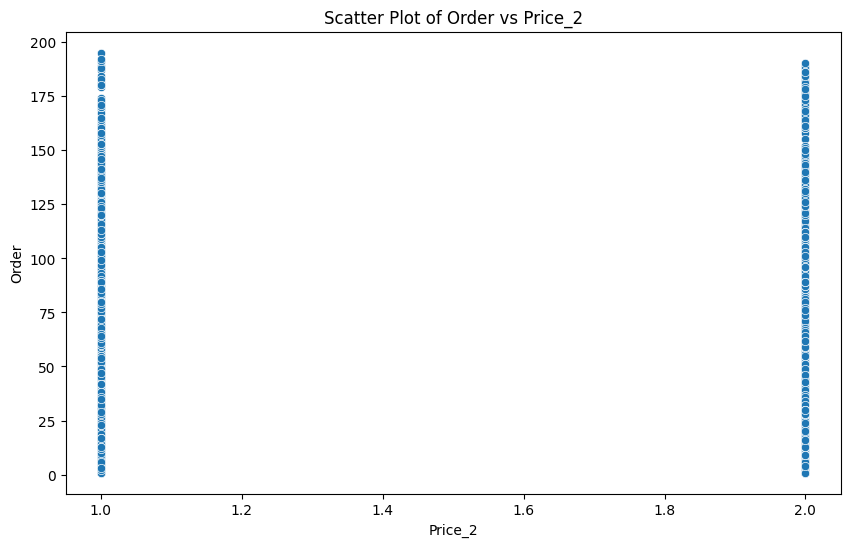

In [52]:
#visualization of correlation between order and price_2
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price_2', y='order', data=train_df)
plt.title('Scatter Plot of Order vs Price_2')
plt.xlabel('Price_2')
plt.ylabel('Order')
plt.show()

##There is no much relation between sequence of clicks and customer conversion 

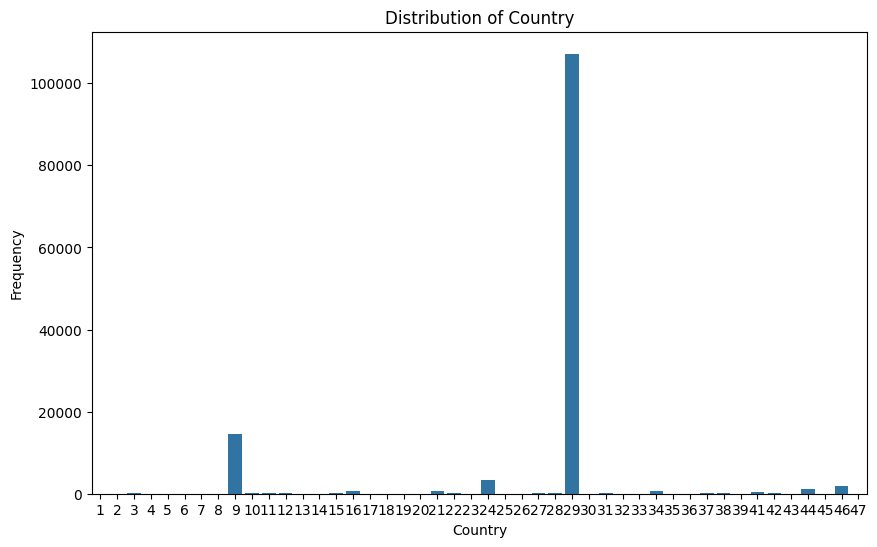

In [53]:
#Distribution of country
plt.figure(figsize=(10, 6))
sns.countplot(x='country', data=train_df)
plt.title('Distribution of Country')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.show()

In [54]:
train_df['country'].value_counts()

country
29    107173
9      14465
24      3272
46      1988
44      1130
16       632
21       622
34       584
41       539
3        193
27       190
12       166
42       141
37       133
31       121
10       120
22       116
28       116
38       114
15        96
11        90
25        54
2         49
32        40
14        35
23        34
19        24
39        24
43        23
17        17
18        15
36        12
7          9
20         8
45         6
47         5
5          4
30         4
6          3
33         3
1          3
35         2
8          1
26         1
13         1
4          1
Name: count, dtype: int64

In [101]:
#page2_clothing_model values
train_df['page2_clothing_model'].value_counts().sample(10)

page2_clothing_model
P79       2
A38     381
B4     2824
P72     300
A37     622
C10     480
B26    1042
C57     646
C7      894
B11    1253
Name: count, dtype: int64

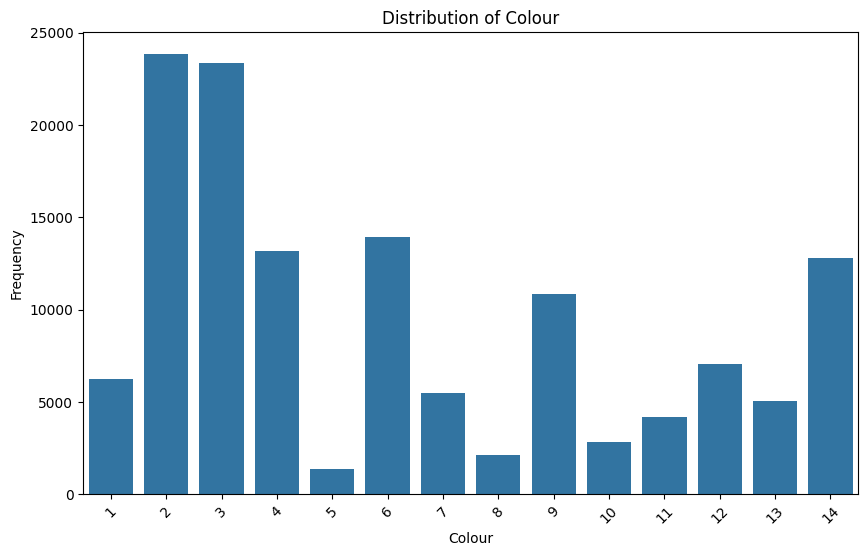

In [56]:
#Distribution of colour
plt.figure(figsize=(10, 6))
sns.countplot(x='colour', data=train_df)
plt.title('Distribution of Colour')
plt.xlabel('Colour')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [57]:
#Colour unique values
train_df['colour'].value_counts()

colour
2     23840
3     23380
6     13966
4     13186
14    12795
9     10865
12     7082
1      6266
7      5474
13     5048
11     4161
10     2824
8      2146
5      1346
Name: count, dtype: int64

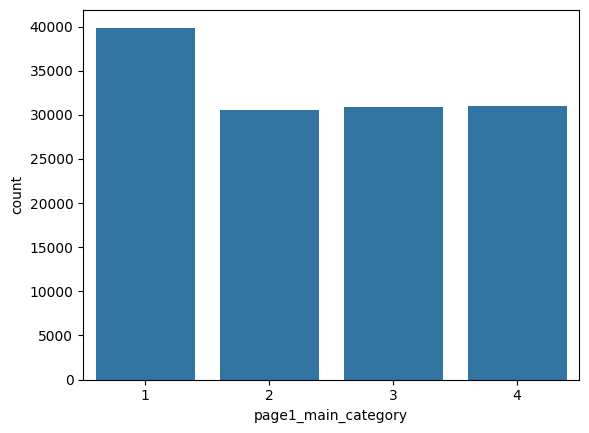

In [58]:
#Visualizing the category distribution
sns.countplot(x="page1_main_category", data=train_df)
plt.show()

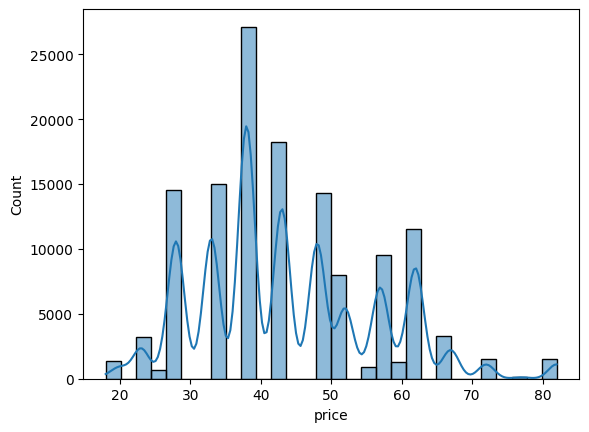

In [59]:
#price distribution

sns.histplot(train_df["price"], bins=30, kde=True)

plt.show()

In [60]:
print(train_df['price'].describe())
print(train_df['price'].skew())
print(train_df['price'].kurt())

count    132379.000000
mean         43.788191
std          12.539390
min          18.000000
25%          33.000000
50%          43.000000
75%          52.000000
max          82.000000
Name: price, dtype: float64
0.5240675621436683
-0.14426122535434782


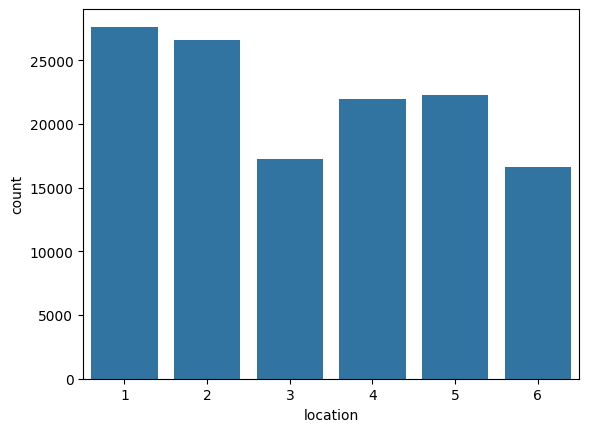

In [61]:
#Distribution of photo location on the page
sns.countplot(x="location", data=train_df)
plt.show()


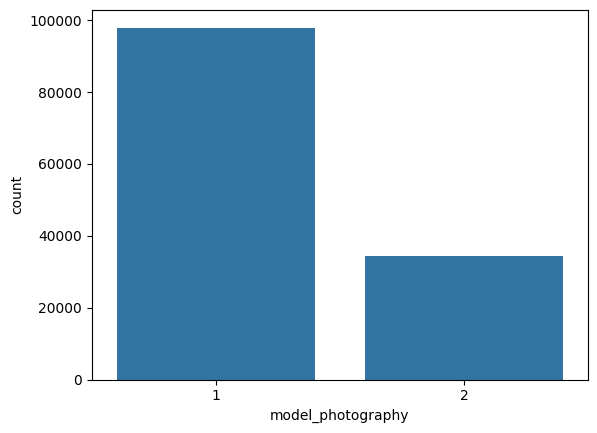

In [62]:
#Distribution of MODEL PHOTOGRAPHY
sns.countplot(x="model_photography", data=train_df)

plt.show()

In [63]:
#values of model_photography
train_df['model_photography'].value_counts()


model_photography
1    97957
2    34422
Name: count, dtype: int64

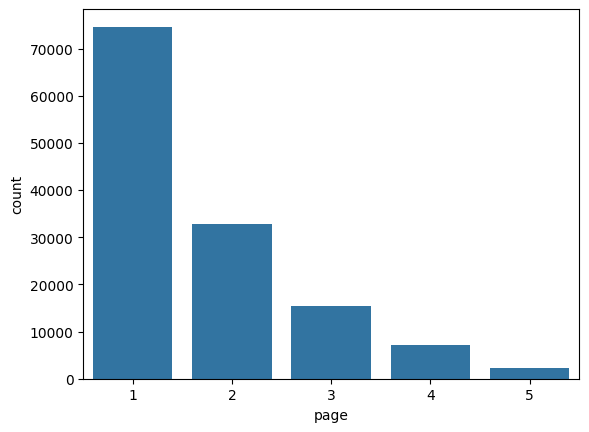

In [64]:
#Distribution by page
sns.countplot(x="page", data=train_df)
plt.show()

In [65]:
#Page wise values
train_df['page'].value_counts()

page
1    74637
2    32882
3    15470
4     7110
5     2280
Name: count, dtype: int64

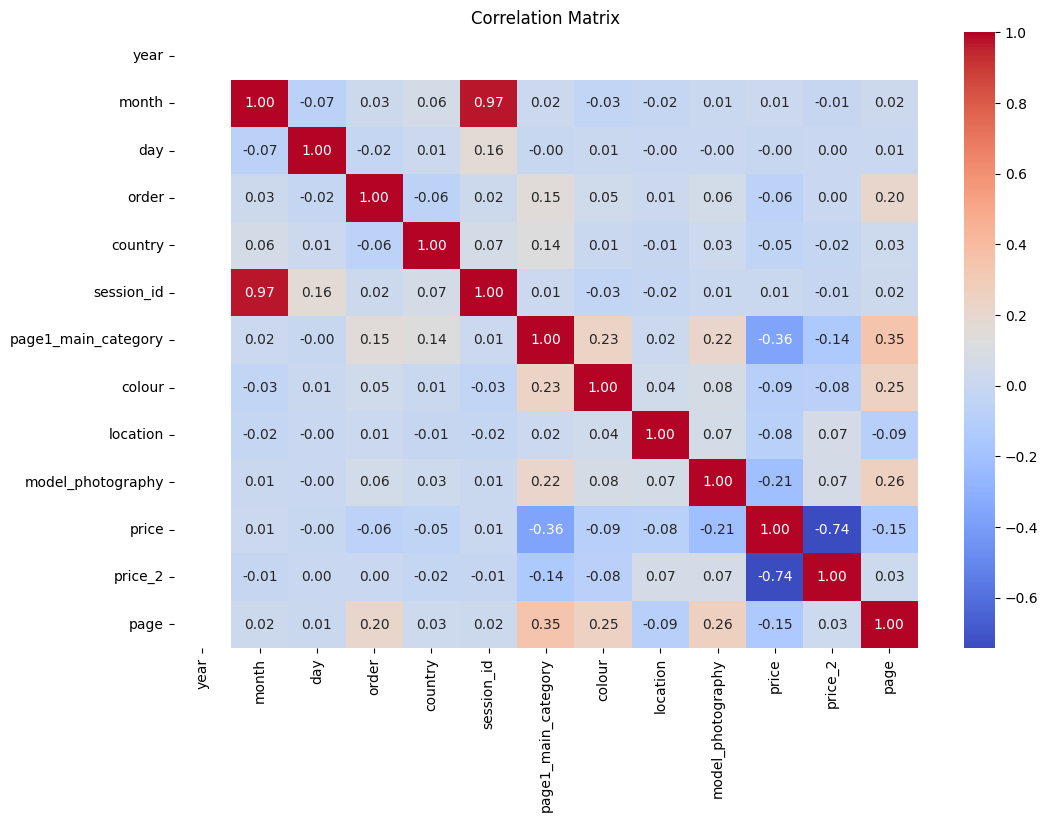

In [66]:
#Correlation between variables
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [67]:
train_df["price_2"].value_counts()

price_2
1    67714
2    64665
Name: count, dtype: int64

In [68]:
train_df["price_2"].value_counts(normalize=True) * 100

price_2
1    51.151618
2    48.848382
Name: proportion, dtype: float64